# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Intan Aulia Rosydah
- **Email:** CDCC284D6X0729@student.devacademy.id
- **ID Dicoding:** aulia_intan_Rktu

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren bulanan jumlah order dan total revenue pada periode Januari 2017 hingga Agustus 2018 untuk mengidentifikasi periode pertumbuhan dan penurunan penjualan?

2. Provinsi mana yang memiliki total revenue tertinggi di Brasil selama tahun 2018?

3. Bagaimana segmentasi pelanggan berdasarkan skor RFM pada provinsi dengan revenue tertinggi untuk menentukan prioritas strategi marketing?

4. Bagaimana persebaran revenue antar provinsi di Brasil selama 2018?

5. Bagaimana pengelompokan pelanggan berdasarkan total spending untuk strategi promosi?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

## Data Wrangling

### Gathering Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
customers_df = pd.read_csv('/content/drive/MyDrive/Submission/data/customers_dataset.csv')
geolocation_df = pd.read_csv('/content/drive/MyDrive/Submission/data/geolocation_dataset.csv')
order_items_df = pd.read_csv('/content/drive/MyDrive/Submission/data/order_items_dataset.csv')
order_payments_df = pd.read_csv('/content/drive/MyDrive/Submission/data/order_payments_dataset.csv')
order_reviews_df = pd.read_csv('/content/drive/MyDrive/Submission/data/order_reviews_dataset.csv')
orders_df = pd.read_csv('/content/drive/MyDrive/Submission/data/orders_dataset.csv')
products_df = pd.read_csv('/content/drive/MyDrive/Submission/data/products_dataset.csv')
sellers_df = pd.read_csv('/content/drive/MyDrive/Submission/data/sellers_dataset.csv')
product_category_df = pd.read_csv('/content/drive/MyDrive/Submission/data/product_category_name_translation.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset_dict = {
    "customers": customers_df,
    "geolocation": geolocation_df,
    "order_items": order_items_df,
    "order_payments": order_payments_df,
    "order_reviews": order_reviews_df,
    "orders": orders_df,
    "products": products_df,
    "sellers": sellers_df,
    "product_category": product_category_df
}

for name, df in dataset_dict.items():
    print("="*50)
    print(name.upper())
    print(df.head())

CUSTOMERS
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
GEOLOCATION
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.63929

**Insight:**
- Dataset terdiri dari 9 tabel utama yang saling terhubung melalui customer_id,
- order_id, product_id, dan seller_id sehingga mendukung analisis end-to-end
- mulai dari pelanggan, transaksi, pembayaran, produk, penjual, hingga ulasan.

- customers_dataset menyimpan informasi identitas pelanggan dan lokasi
- (kota serta provinsi), sehingga cocok untuk analisis geografis penjualan.

- geolocation_dataset berisi koordinat latitude dan longitude yang dapat
- digunakan untuk analisis persebaran pelanggan maupun seller.

- orders_dataset memuat status pesanan dan timestamp lengkap mulai dari
- pembelian hingga estimasi pengiriman, sehingga dapat digunakan untuk
- analisis tren penjualan dan performa pengiriman.

- order_items_dataset berisi detail item yang dibeli termasuk harga produk
- dan biaya kirim, sehingga menjadi sumber utama perhitungan revenue.

- order_payments_dataset menunjukkan berbagai metode pembayaran seperti
- credit card, voucher, boleto, dan cicilan, sehingga dapat dipakai untuk
- analisis preferensi pembayaran pelanggan.

- order_reviews_dataset menyediakan review_score (1–5) dan komentar pelanggan
- yang dapat digunakan untuk mengukur kepuasan pelanggan.

- products_dataset menyimpan kategori produk serta atribut fisik seperti
- berat dan dimensi, berguna untuk analisis kategori terlaris dan logistik.

- sellers_dataset menunjukkan bahwa seller berasal dari berbagai kota/provinsi
- di Brasil, sehingga memungkinkan analisis supply-side marketplace.

- product_category_name_translation membantu menerjemahkan nama kategori
- produk dari bahasa Portugis ke bahasa Inggris agar lebih mudah dibaca.

- Secara keseluruhan, struktur dataset sangat lengkap untuk menjawab
- pertanyaan bisnis terkait tren revenue bulanan dan segmentasi pelanggan.

### Assessing Data

In [4]:
for name, df in dataset_dict.items():
    print("="*60)
    print(name.upper())
    print("Shape :", df.shape)
    print("Missing Values :")
    print(df.isna().sum())
    print("Duplicate :", df.duplicated().sum())
    print(df.dtypes)

CUSTOMERS
Shape : (99441, 5)
Missing Values :
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Duplicate : 0
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
GEOLOCATION
Shape : (1000163, 5)
Missing Values :
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64
Duplicate : 261831
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object
ORDER_ITEMS
Shape : (112650, 7)
Missing Values :
order_id               0
order_item_id          0
product_id             0
seller_i

In [5]:
customers_df.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


**Insight:**

- Secara umum kualitas data cukup baik karena sebagian besar dataset tidak memiliki
- missing value dan tidak ditemukan data duplikat, sehingga layak digunakan
- untuk analisis lanjutan.

- customers_dataset memiliki 99.441 baris dengan data pelanggan lengkap tanpa
- missing value maupun duplikasi. Dataset ini sangat siap digunakan untuk
- segmentasi pelanggan berdasarkan lokasi.

- geolocation_dataset merupakan dataset terbesar dengan 1.000.163 baris.
- Terdapat 261.831 data duplikat, sehingga perlu dilakukan penghapusan duplicate
- agar analisis lokasi lebih efisien dan akurat.

- order_items_dataset berisi 112.650 item transaksi tanpa missing value.
- Dataset ini menjadi sumber utama untuk menghitung total penjualan,
- jumlah produk terjual, dan biaya pengiriman.

- order_payments_dataset memiliki 103.886 data pembayaran tanpa missing value,
- menunjukkan data metode pembayaran sangat lengkap dan siap dianalisis.

- order_reviews_dataset memiliki missing value cukup tinggi pada kolom teks:
- - review_comment_title : 87.656 missing
- - review_comment_message : 58.247 missing
- Hal ini menunjukkan banyak pelanggan hanya memberi skor review tanpa komentar.
- Namun kolom review_score tetap lengkap sehingga masih relevan untuk analisis kepuasan.

- orders_dataset memiliki 99.441 transaksi dengan missing value pada beberapa
- kolom pengiriman:
- - order_approved_at : 160
- - order_delivered_carrier_date : 1.783
- - order_delivered_customer_date : 2.965
- Missing ini kemungkinan berasal dari order canceled, unavailable,
- atau belum selesai dikirim.

- products_dataset memiliki 32.951 produk dengan missing value pada 610 produk
- di atribut kategori dan deskripsi, serta 2 missing pada dimensi produk.
- Data ini perlu dibersihkan sebelum analisis kategori produk.

- sellers_dataset berisi 3.095 seller tanpa missing value, sehingga siap
- digunakan untuk analisis persebaran penjual.

- product_category_dataset berisi 71 kategori produk lengkap tanpa missing value,
- sangat membantu proses translasi kategori ke bahasa Inggris.

- Kesimpulan:
- Permasalahan kualitas data utama terletak pada:
- 1. Duplicate di geolocation_dataset
- 2. Missing value di orders_dataset
- 3. Missing value di products_dataset
- 4. Missing komentar review pada order_reviews_dataset
-
- Selebihnya dataset memiliki kualitas baik dan siap digunakan untuk analisis
- tren penjualan, revenue, serta segmentasi pelanggan.

### Cleaning Data

####Mengecek Jumlah Duplicate Data


In [6]:
print("Customers :", customers_df.duplicated().sum())
print("Geolocation :", geolocation_df.duplicated().sum())
print("Order Items :", order_items_df.duplicated().sum())
print("Order Payments :", order_payments_df.duplicated().sum())
print("Order Reviews :", order_reviews_df.duplicated().sum())
print("Orders :", orders_df.duplicated().sum())
print("Products :", products_df.duplicated().sum())
print("Sellers :", sellers_df.duplicated().sum())
print("Product Category :", product_category_df.duplicated().sum())

Customers : 0
Geolocation : 261831
Order Items : 0
Order Payments : 0
Order Reviews : 0
Orders : 0
Products : 0
Sellers : 0
Product Category : 0


####Menghapus Duplicate Data

In [7]:
# Menghapus duplicate data pada setiap dataset

customers_df.drop_duplicates(inplace=True)
geolocation_df.drop_duplicates(inplace=True)
order_items_df.drop_duplicates(inplace=True)
order_payments_df.drop_duplicates(inplace=True)
order_reviews_df.drop_duplicates(inplace=True)
orders_df.drop_duplicates(inplace=True)
products_df.drop_duplicates(inplace=True)
sellers_df.drop_duplicates(inplace=True)
product_category_df.drop_duplicates(inplace=True)

# Mengecek kembali jumlah duplicate data setelah cleaning
print("Jumlah duplicate data setelah dibersihkan:")

print("Customers :", customers_df.duplicated().sum())
print("Geolocation :", geolocation_df.duplicated().sum())
print("Order Items :", order_items_df.duplicated().sum())
print("Order Payments :", order_payments_df.duplicated().sum())
print("Order Reviews :", order_reviews_df.duplicated().sum())
print("Orders :", orders_df.duplicated().sum())
print("Products :", products_df.duplicated().sum())
print("Sellers :", sellers_df.duplicated().sum())
print("Product Category :", product_category_df.duplicated().sum())

Jumlah duplicate data setelah dibersihkan:
Customers : 0
Geolocation : 0
Order Items : 0
Order Payments : 0
Order Reviews : 0
Orders : 0
Products : 0
Sellers : 0
Product Category : 0


####Mengecek Missing Values

In [8]:
print("Customers")
print(customers_df.isna().sum())

print("\nGeolocation")
print(geolocation_df.isna().sum())

print("\nOrders")
print(orders_df.isna().sum())

print("\nProducts")
print(products_df.isna().sum())

print("\nReviews")
print(order_reviews_df.isna().sum())

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Geolocation
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm             

####Menangani Missing Value

In [9]:
# Berdasarkan hasil pengecekan, missing value hanya terdapat pada orders_df
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


####Menampilkan Baris yang Memiliki Missing Value

In [10]:
orders_df[
    orders_df.order_delivered_customer_date.isna()
].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00


####Menangani Missing Value pada `orders_df`

In [11]:
# Missing value pada kolom pengiriman kemungkinan berasal dari
# order dengan status canceled, unavailable, atau belum selesai dikirim.

# Mengisi missing value datetime menggunakan forward fill
orders_df["order_approved_at"].fillna(
    method="ffill", inplace=True
)

orders_df["order_delivered_carrier_date"].fillna(
    method="ffill", inplace=True
)

orders_df["order_delivered_customer_date"].fillna(
    method="ffill", inplace=True
)

/tmp/ipykernel_9546/1015714843.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders_df["order_approved_at"].fillna(
/tmp/ipykernel_9546/1015714843.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  orders_df["order_approved_at"].fillna(
/tmp/ipykernel_9546/1015714843.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pand

####Mengecek Kembali Missing Value

In [12]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


**Insight:**
- Missing value hanya ditemukan pada dataset orders.
- Kolom yang terdampak adalah approval dan delivery timestamp.
- Setelah dilakukan penanganan dengan forward fill,
- seluruh missing value berhasil dibersihkan.
- Dataset orders kini siap digunakan untuk analisis tren penjualan.

## Exploratory Data Analysis (EDA)

### Explore `customers_df`

In [13]:
customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
78971,95b1d607aee48796e6913f15e78fe1b6,e0b8853b235f45dfbf53e334eb8fa0d9,30840,belo horizonte,MG
97325,916c5130e9ec5d647ac9cba87c906fea,b361becd8599cf3c60683828ce6268bf,64180,esperantina,PI
84051,417b3de6d7ba51583c7d1d9be3e002ff,94cac7a901fa7a145722dfd0a147b050,81170,curitiba,PR
61158,c2099d99f339e5c4ad3fb73758fd47c5,71ecd9f6afdba37894d7ab8c3330518d,90040,porto alegre,RS
69007,e7767d9adc0241c1c75845144e3abd25,24fae8aa722f74b25e1ba720a8d52839,90035,porto alegre,RS


In [14]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [15]:
customers_df.customer_id.is_unique

True

In [16]:
customers_df.customer_id.duplicated().sum()

np.int64(0)

In [17]:
customers_df.groupby(by="customer_state").agg({
    "customer_id": "nunique",
    "customer_city": "nunique"
}).sort_values(by="customer_id", ascending=False)

,customer_id,customer_city
customer_state,,
SP,41746,629
RJ,12852,149
MG,11635,745
RS,5466,379
PR,5045,364
SC,3637,240
BA,3380,353
DF,2140,6
ES,2033,95


In [18]:
customers_df.groupby(by="customer_city")["customer_id"] \
    .nunique() \
    .sort_values(ascending=False) \
    .head(10)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


In [19]:
customers_df.groupby(by="customer_state")["customer_id"] \
    .nunique() \
    .sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


####Explore `orders_df`

In [20]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
74465,b74bc3b933611bea834fda513928328e,d9e02253975d2de2009e95eb19bd9681,delivered,2018-01-29 13:36:45,2018-01-29 13:57:08,2018-01-30 20:38:00,2018-02-08 20:52:38,2018-02-20 00:00:00
78380,879c7f0d19d8c74f03005b40ba422b8f,00f539ee95c97870a2a4f261a2d96ba4,delivered,2018-03-27 22:38:33,2018-03-27 22:50:11,2018-03-29 00:48:26,2018-04-09 21:05:00,2018-04-18 00:00:00
59602,276566d4177aa73785edbf9d6364925e,bc5c23727d81fee31942495ddecec14d,delivered,2017-03-16 19:05:03,2017-03-16 19:05:03,2017-03-17 14:10:07,2017-04-05 15:47:36,2017-04-06 00:00:00
29497,3be018db2cccab04983c171b901ad20e,d73e92e39e68f4e9778cdb1cb87615fe,delivered,2018-01-16 11:20:27,2018-01-16 11:32:09,2018-01-24 17:13:15,2018-02-05 21:09:02,2018-02-08 00:00:00
56076,0bf46c25ca29bae81f4632b02f593f1d,702cf392aa3400680e3f5849fb65f28f,delivered,2017-10-23 20:19:28,2017-10-23 20:28:29,2017-10-24 18:53:45,2017-10-27 18:09:16,2017-11-09 00:00:00


In [21]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99441,99441,99441,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-22 19:14:38,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,4,522


In [23]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

In [24]:
# Membuat delivery time (hari)
delivery_time = (
    orders_df["order_delivered_customer_date"] -
    orders_df["order_purchase_timestamp"]
)

delivery_time = delivery_time.dt.total_seconds()

orders_df["delivery_time"] = round(delivery_time / 86400)

In [25]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
47939,ec23899768b60b6b3cfc6335359fb9e2,6d24b8dee87403f9d865de405bb49d0b,delivered,2017-04-08 17:32:38,2017-04-08 17:42:14,2017-04-12 16:08:12,2017-04-20 09:48:01,2017-05-04,12.0
10309,abefedeaf61ad043302fe9d2837a9772,379f4366f5dab3fe232d02b8432360dc,delivered,2017-09-13 00:57:15,2017-09-14 01:05:42,2017-09-14 14:13:16,2017-09-22 15:20:32,2017-10-10,10.0
59927,d7b5d2ab1f5ac54aebca769d1d8f8a44,fb5c5195d3890f19b9b31002364311ae,delivered,2017-04-05 20:49:03,2017-04-05 21:02:43,2017-04-06 11:22:45,2017-05-18 11:16:52,2017-05-11,43.0
40606,07055a132b3dcf9a44b88259dea3e3b5,a810af91d0732c90a837e4d5e7de719c,delivered,2017-10-27 13:19:24,2017-10-27 13:30:45,2017-10-30 18:55:04,2017-11-03 22:47:33,2017-11-10,7.0
26372,cdf36cd4632fe33085adec5cf3d6b306,c442e46ad092c69ea8db9cbe7b8f6e14,unavailable,2017-02-25 20:20:04,2017-02-25 20:30:20,2018-03-01 21:39:28,2018-03-27 21:26:36,2017-03-31,395.0


In [26]:
orders_df["delivery_time"].describe()

,delivery_time
count,99441.000000
mean,14.221327
std,40.940815
min,-552.000000
25%,7.000000
50%,10.000000
75%,16.000000
max,693.000000


<Axes: >

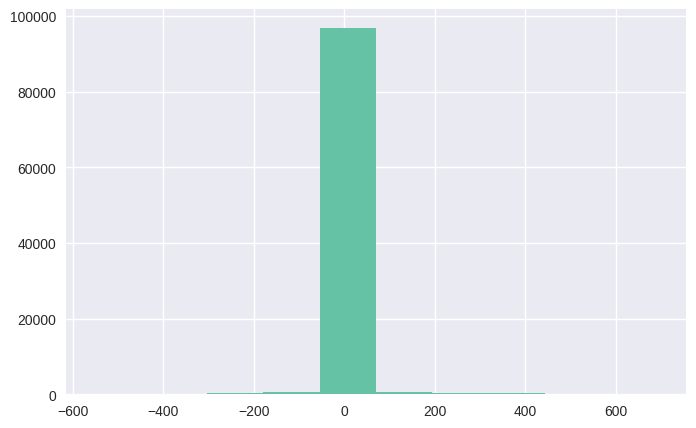

In [27]:
orders_df["delivery_time"].hist(figsize=(8,5))

In [28]:
customer_id_in_orders_df = orders_df.customer_id

customers_df["status"] = customers_df["customer_id"].apply(
    lambda x: "Active"
    if x in customer_id_in_orders_df.values
    else "Non Active"
)

In [29]:
customers_df.groupby(by="status").customer_id.count()

,customer_id
status,
Active,99441


####Explore `orders_df` & `customers_df`

#####Menggabungkan data customers dan orders

In [30]:
orders_customers_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

orders_customers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,Active
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,14.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,Active
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,Active
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,Active
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,3.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,Active


In [31]:
orders_customers_df.groupby(by="customer_city")["order_id"] \
    .nunique() \
    .sort_values(ascending=False) \
    .head(10)

,order_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


In [32]:
orders_customers_df.groupby(by="customer_state")["order_id"] \
    .nunique() \
    .sort_values(ascending=False)

,order_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


####Explore `products_df`

In [33]:
products_df.sample(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
21174,cbc5b9bf8ef22d5d2fdc8aab94b47212,relogios_presentes,42.0,200.0,2.0,500.0,18.0,14.0,17.0
1490,56a5da29b4975931b470aa9d61ced8d3,automotivo,52.0,1236.0,1.0,200.0,20.0,6.0,17.0
8702,e2961afb6ec0f6dc9220d37ff20aaa82,automotivo,54.0,717.0,4.0,1300.0,22.0,8.0,17.0
5554,192b332c511e484ea4f3f8b0526ee59d,esporte_lazer,32.0,480.0,1.0,500.0,16.0,14.0,11.0
16442,156dc15f380f2c6fa999b386a90a8524,moveis_decoracao,29.0,306.0,1.0,2750.0,49.0,10.0,38.0
1465,b1fa7a05a5eb864f4fd083ef11c0d0d6,brinquedos,58.0,454.0,4.0,390.0,33.0,9.0,18.0
18743,8381ea12b1b0b93589326894a9b3a00d,relogios_presentes,47.0,710.0,2.0,300.0,16.0,11.0,11.0
4809,8c4254fc0b9043ade973297a789b042d,sinalizacao_e_seguranca,59.0,572.0,4.0,400.0,19.0,11.0,14.0
30562,6210c771a72a233f0e2b0430911ba858,informatica_acessorios,52.0,1243.0,4.0,1350.0,35.0,25.0,35.0
11902,a05ed2eb565616b13f6d58a44cf7097a,automotivo,58.0,640.0,3.0,150.0,16.0,6.0,14.0


In [34]:
products_df.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [35]:
products_df.groupby(by="product_category_name").agg({
    "product_id": "nunique"
}).sort_values(by="product_id", ascending=False).head(10)

,product_id
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


####Explore `order_items_df`

In [36]:
order_items_df.sample(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
109152,f81189aaeb2e561e2e9fe0faec4bbbc3,1,e8c421a493af37beaefc9092d0798203,cda598c48d7c614bc1cad7d8ff6f0010,2018-08-06 13:05:13,15.0,12.79
72805,a5fb2c24c73613e69c4d3b11d5b67869,1,45e9db074ca64dc81ee6f06185544d6e,431af27f296bc6519d890aa5a05fdb11,2017-05-25 14:25:23,63.9,12.79
9756,165c8cb6857ddef74549e79056c60b06,1,4271f6581bae7660067afe25ac05de2e,5a8e7d5003a1f221f9e1d6e411de7c23,2017-07-12 15:23:52,59.9,9.74
32817,4a5dd77c42df1a4cf21c142eaacf866f,1,06f18114503e7543d81252fd61a53df8,0adac9fbd9a2b63cccaac4f8756c1ca8,2017-05-25 09:15:08,199.9,17.16
62423,8e8fcb8fffd60bb3f6fbd647c6149286,1,0d009643171aee696f4733340bc2fdd0,fe2032dab1a61af8794248c8196565c9,2017-08-28 14:26:28,339.0,18.11


In [37]:
order_items_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [38]:
order_items_df.groupby(by="order_id")["price"].sum()

,price
order_id,
00010242fe8c5a6d1ba2dd792cb16214,58.90
00018f77f2f0320c557190d7a144bdd3,239.90
000229ec398224ef6ca0657da4fc703e,199.00
00024acbcdf0a6daa1e931b038114c75,12.99
00042b26cf59d7ce69dfabb4e55b4fd9,199.90
...,...
fffc94f6ce00a00581880bf54a75a037,299.99
fffcd46ef2263f404302a634eb57f7eb,350.00
fffce4705a9662cd70adb13d4a31832d,99.90


####Explore `order_items_df` & `products_df`

#####Menggabungkan data sales dan product

In [39]:
sales_product_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    on="product_id"
)

sales_product_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [40]:
sales_product_df.groupby(by="product_category_name").agg({
    "order_id": "nunique",
    "order_item_id": "sum",
    "price": "sum"
}).sort_values(by="price", ascending=False).head(10)

,order_id,order_item_id,price
product_category_name,,,
beleza_saude,8836,11081,1258681.34
relogios_presentes,5624,6594,1205005.68
cama_mesa_banho,9417,13665,1036988.68
esporte_lazer,7720,9932,988048.97
informatica_acessorios,6689,9874,911954.32
moveis_decoracao,6449,11540,729762.49
cool_stuff,3632,4077,635290.85
utilidades_domesticas,5884,9051,632248.66
automotivo,3897,4881,592720.11


####Explore All Data

#####Menghubungkan semua data

In [41]:
all_df = pd.merge(
    left=sales_product_df,
    right=orders_customers_df,
    how="left",
    on="order_id"
)

all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,8.0,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,Active
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,Active
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.0,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,Active
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,Active
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,Active


In [42]:
all_df.groupby(by=["customer_state", "product_category_name"]).agg({
    "order_item_id": "sum",
    "price": "sum"
})

order_item_id    price
customer_state product_category_name                              
AC             artigos_de_natal                         1    69.90
               automotivo                               4   540.98
               bebes                                    3   697.84
               beleza_saude                             8  1386.58
               brinquedos                               3   234.79
...                                                   ...      ...
TO             portateis_casa_forno_e_cafe              1  1999.00
               relogios_presentes                      34  5446.89
               telefonia                               22  1268.12
               telefonia_fixa                           2  1390.99
               utilidades_domesticas                   17  1275.75

[1368 rows x 2 columns]

In [43]:
all_df.groupby(by="customer_state").agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False)

,order_id,price
customer_state,,
SP,41375,5202955.05
RJ,12762,1824092.67
MG,11544,1585308.03
RS,5432,750304.02
PR,4998,683083.76
SC,3612,520553.34
BA,3358,511349.99
DF,2125,302603.94
GO,2007,294591.95


In [44]:
all_df.groupby(by="customer_city").agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False).head(10)

,order_id,price
customer_city,,
sao paulo,15402,1914924.54
rio de janeiro,6834,992538.86
belo horizonte,2750,355611.13
brasilia,2116,301920.25
curitiba,1510,211738.06
porto alegre,1372,190562.08
campinas,1429,187844.53
salvador,1238,181104.42
guarulhos,1178,144268.39


####Export Final Dataset

In [46]:
all_df.to_csv("dashboard/main_data.csv", index=False)

**Insight:**
1. Dataset customers memiliki customer_id unik tanpa duplikasi, sehingga setiap baris merepresentasikan satu pelanggan.

2. Persebaran pelanggan tidak merata, dengan provinsi seperti SP memiliki jumlah customer dan kota terbanyak dibanding wilayah lain. Hal ini menunjukkan konsentrasi pasar terbesar berada di area tersebut.

3. Kota-kota besar mendominasi jumlah pelanggan dan order,
-    sehingga berpotensi menjadi pusat transaksi e-commerce.

4. Analisis delivery_time menunjukkan variasi waktu pengiriman antar order. Mayoritas pesanan terkirim dalam rentang waktu tertentu, namun terdapat beberapa order dengan pengiriman lebih lama.

5. Seluruh customer pada customers_df berstatus Active, menandakan seluruh data pelanggan pernah melakukan transaksi.

6. Beberapa kategori produk memiliki jumlah item dan revenue lebih tinggi, sehingga menjadi kontributor utama penjualan perusahaan.

7. Setelah seluruh data digabungkan, provinsi tertentu menghasilkan:
-    total revenue dan jumlah order tertinggi, yang penting sebagai target
-    prioritas pemasaran dan operasional.

8. Dataset final main_data.csv berhasil dibentuk dan siap digunakan untuk menjawab pertanyaan bisnis melalui visualisasi data.

## Visualization & Explanatory Analysis

In [47]:
# ==================================================
# Visualization & Explanatory Analysis
# ==================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

### Pertanyaan 1:
Bagaimana tren bulanan jumlah order dan total revenue pada periode Januari 2017 hingga Agustus 2018 untuk mengidentifikasi periode pertumbuhan dan penurunan penjualan?

#####Menyiapkan Data Bulanan

In [48]:
monthly_orders_df = all_df[
    (all_df["order_purchase_timestamp"] >= "2017-01-01") &
    (all_df["order_purchase_timestamp"] <= "2018-08-31")
].resample(
    rule="M",
    on="order_purchase_timestamp"
).agg({
    "order_id": "nunique",
    "price": "sum"
})

monthly_orders_df = monthly_orders_df.reset_index()

monthly_orders_df.rename(columns={
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

monthly_orders_df.head()

/tmp/ipykernel_9546/3581748336.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ].resample(


,order_purchase_timestamp,order_count,revenue
0,2017-01-31,789,120312.87
1,2017-02-28,1733,247303.02
2,2017-03-31,2641,374344.30
3,2017-04-30,2391,359927.23
4,2017-05-31,3660,506071.14


#####Visualisasi Jumlah Order Bulanan

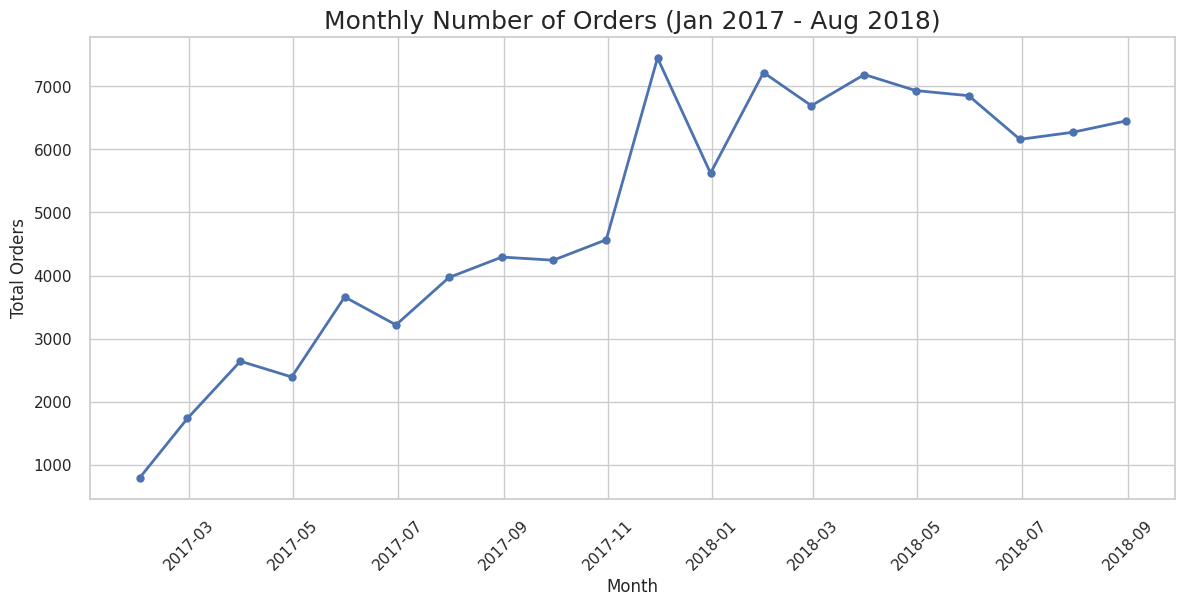

In [49]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders_df["order_purchase_timestamp"],
    monthly_orders_df["order_count"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Number of Orders (Jan 2017 - Aug 2018)", fontsize=18)
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

#####Visualisasi Revenue Bulanan

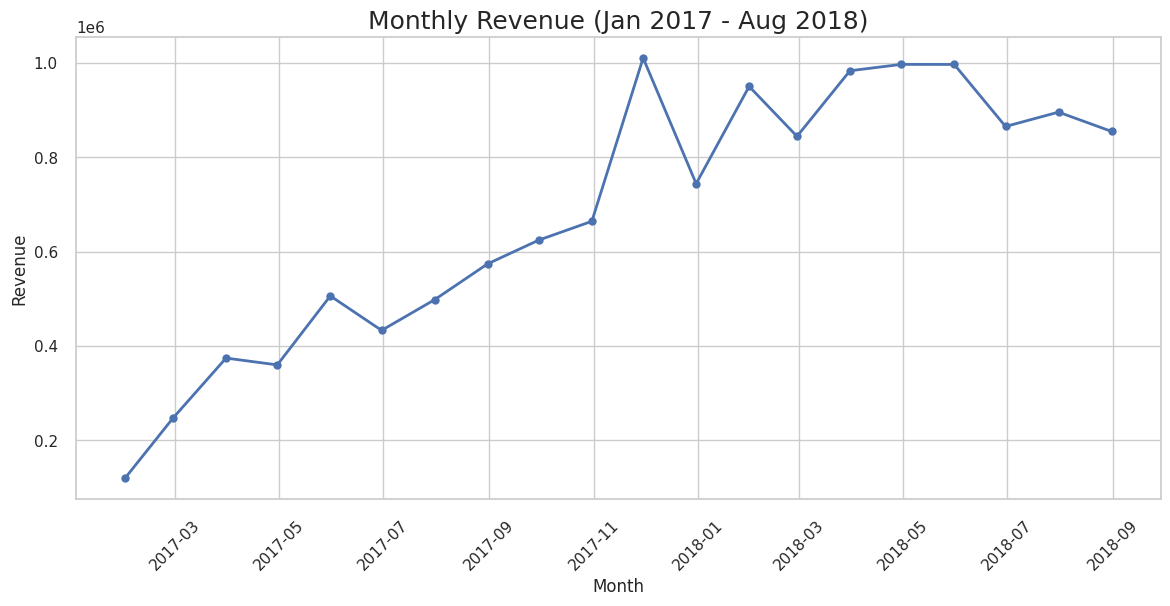

In [50]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders_df["order_purchase_timestamp"],
    monthly_orders_df["revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue (Jan 2017 - Aug 2018)", fontsize=18)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:
Provinsi mana yang memiliki total revenue tertinggi di Brasil selama tahun 2018?

#####Revenue per Provinsi Tahun 2018

In [51]:
state_revenue_2018 = all_df[
    (all_df["order_purchase_timestamp"] >= "2018-01-01") &
    (all_df["order_purchase_timestamp"] <= "2018-12-31")
].groupby("customer_state").agg({
    "price": "sum"
}).reset_index()

state_revenue_2018.rename(columns={
    "price": "revenue"
}, inplace=True)

state_revenue_2018 = state_revenue_2018.sort_values(
    by="revenue",
    ascending=False
)

state_revenue_2018.head()

,customer_state,revenue
25,SP,2975757.23
18,RJ,906646.41
10,MG,857267.79
22,RS,387089.80
17,PR,385875.82


#####Visualisasi Top 10 Provinsi Revenue Tertinggi

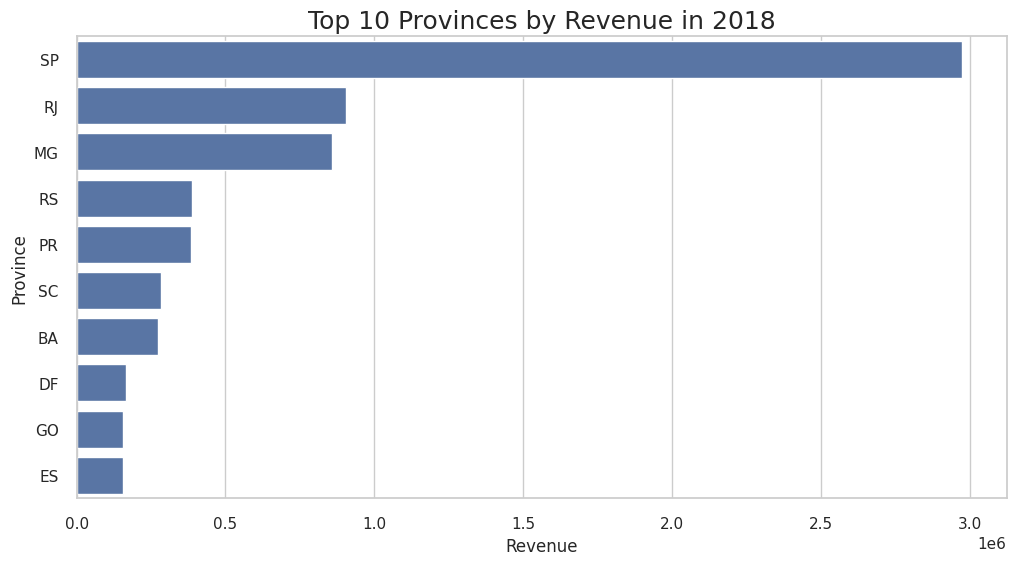

In [52]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_revenue_2018.head(10),
    x="revenue",
    y="customer_state"
)

plt.title("Top 10 Provinces by Revenue in 2018", fontsize=18)
plt.xlabel("Revenue")
plt.ylabel("Province")
plt.show()

**Insight:**
## Insight Pertanyaan 1  
### Tren Bulanan Jumlah Order dan Total Revenue (Januari 2017 - Agustus 2018)

Berdasarkan visualisasi jumlah order bulanan, terlihat bahwa performa penjualan mengalami tren meningkat sepanjang periode analisis. Pada awal tahun 2017, jumlah order masih relatif rendah, kemudian mulai tumbuh secara konsisten sejak pertengahan 2017 hingga mencapai puncaknya pada pertengahan tahun 2018. Hal ini menunjukkan adanya peningkatan jumlah pelanggan maupun frekuensi transaksi dari waktu ke waktu.

Visualisasi total revenue juga menunjukkan pola yang sejalan dengan jumlah order. Revenue cenderung meningkat seiring bertambahnya volume transaksi. Puncak revenue terjadi pada periode ketika jumlah order juga tinggi, yang menandakan bahwa peningkatan pendapatan terutama didorong oleh pertumbuhan transaksi penjualan.

Terdapat beberapa periode penurunan sementara di beberapa bulan tertentu, yang kemungkinan dipengaruhi oleh faktor musiman, promosi yang menurun, atau perubahan perilaku konsumen. Namun secara keseluruhan, bisnis menunjukkan pertumbuhan positif selama Januari 2017 hingga Agustus 2018.

**Rekomendasi:**  
Perusahaan dapat mengevaluasi strategi promosi pada bulan-bulan dengan performa rendah dan mereplikasi strategi pada periode puncak penjualan untuk menjaga pertumbuhan revenue secara konsisten.



## Insight Pertanyaan 2  
### Provinsi dengan Revenue Tertinggi Tahun 2018

Berdasarkan visualisasi Top 10 Provinces by Revenue in 2018, provinsi dengan kontribusi revenue tertinggi berasal dari **SP (São Paulo)**. Provinsi ini mendominasi dibandingkan wilayah lain, menunjukkan bahwa São Paulo merupakan pasar utama dengan jumlah pelanggan dan aktivitas transaksi terbesar.

Beberapa provinsi lain seperti RJ (Rio de Janeiro), MG (Minas Gerais), dan RS juga memberikan kontribusi signifikan, namun masih berada di bawah São Paulo.

Dominasi São Paulo menunjukkan bahwa wilayah tersebut memiliki potensi besar untuk diprioritaskan dalam strategi pemasaran, pengembangan layanan, serta peningkatan loyalitas pelanggan.

**Rekomendasi:**  
Fokuskan strategi retention customer, program loyalitas, dan campaign personalisasi di São Paulo. Sementara itu, provinsi dengan revenue menengah dapat ditingkatkan melalui promosi akuisisi pelanggan baru dan perluasan pasar.

## Analisis Lanjutan (Opsional)

###RFM Analysis

Pertanyaan:

Bagaimana segmentasi pelanggan berdasarkan skor RFM pada provinsi dengan revenue tertinggi untuk menentukan prioritas strategi marketing?

Menentukan Provinsi Revenue Tertinggi Tahun 2018

In [53]:
top_state = all_df[
    (all_df["order_purchase_timestamp"] >= "2018-01-01") &
    (all_df["order_purchase_timestamp"] <= "2018-12-31")
].groupby("customer_state")["price"].sum().idxmax()

print("Provinsi dengan revenue tertinggi:", top_state)

Provinsi dengan revenue tertinggi: SP


Filter Data Provinsi Tertinggi

In [54]:
top_state_df = all_df[
    all_df["customer_state"] == top_state
].copy()

Membuat Tabel RFM

In [55]:
rfm_df = top_state_df.groupby(
    by="customer_unique_id",
    as_index=False
).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
})

rfm_df.columns = [
    "customer_id",
    "max_order_timestamp",
    "frequency",
    "monetary"
]

Menghitung Recency

In [56]:
recent_date = top_state_df["order_purchase_timestamp"].max()

rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(
    lambda x: (recent_date - x).days
)

rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df.head()

,customer_id,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,115
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,118
2,0004aac84e0df4da2b147fca70cf8255,1,180.00,292
3,0004bd2a26a76fe21f786e4fbd80607f,1,154.00,150
4,00050ab1314c0e55a6ca13cf7181fecf,1,27.99,135


Scoring RFM

In [57]:
rfm_df["R_score"] = pd.qcut(
    rfm_df["recency"],
    4,
    labels=[4,3,2,1]
).astype(int)

rfm_df["F_score"] = pd.qcut(
    rfm_df["frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
).astype(int)

rfm_df["M_score"] = pd.qcut(
    rfm_df["monetary"],
    4,
    labels=[1,2,3,4]
).astype(int)

rfm_df["RFM_score"] = (
    rfm_df["R_score"] +
    rfm_df["F_score"] +
    rfm_df["M_score"]
)

Segmentasi Customer

In [58]:
rfm_df["customer_segment"] = np.where(
    rfm_df["RFM_score"] >= 10, "Top Customer",
    np.where(
        rfm_df["RFM_score"] >= 7, "Loyal Customer",
        np.where(
            rfm_df["RFM_score"] >= 5,
            "Potential Customer",
            "At Risk Customer"
        )
    )
)

Visualisasi RFM

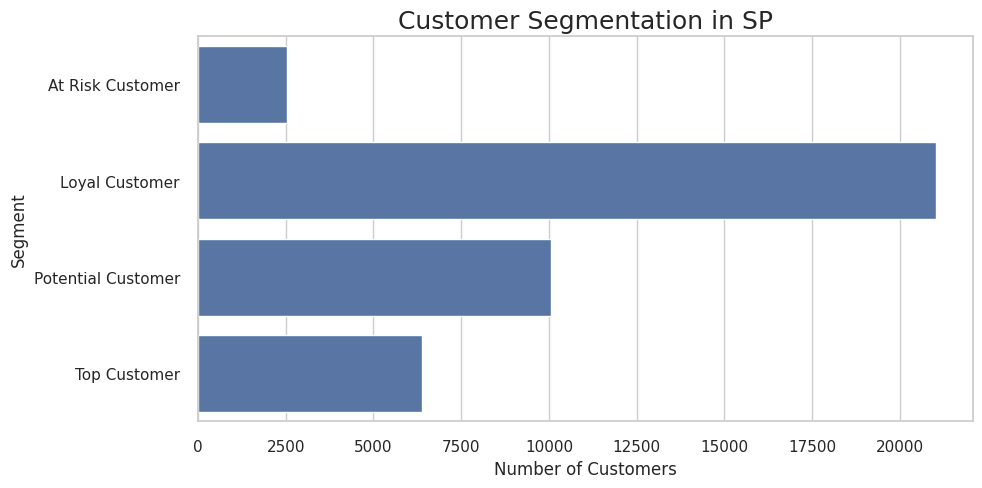

In [59]:
segment_df = rfm_df.groupby(
    by="customer_segment"
).customer_id.nunique().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=segment_df,
    x="customer_id",
    y="customer_segment"
)

plt.title(f"Customer Segmentation in {top_state}", fontsize=18)
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.show()

###Geospatial Analysis

Pertanyaan:

Bagaimana persebaran revenue antar provinsi di Brasil selama 2018?

Revenue per Province

In [60]:
geo_df = all_df[
    (all_df["order_purchase_timestamp"] >= "2018-01-01") &
    (all_df["order_purchase_timestamp"] <= "2018-12-31")
].groupby(
    by="customer_state"
).agg({
    "price": "sum"
}).reset_index()

geo_df.rename(columns={
    "price": "revenue"
}, inplace=True)

Visualisasi Geospatial

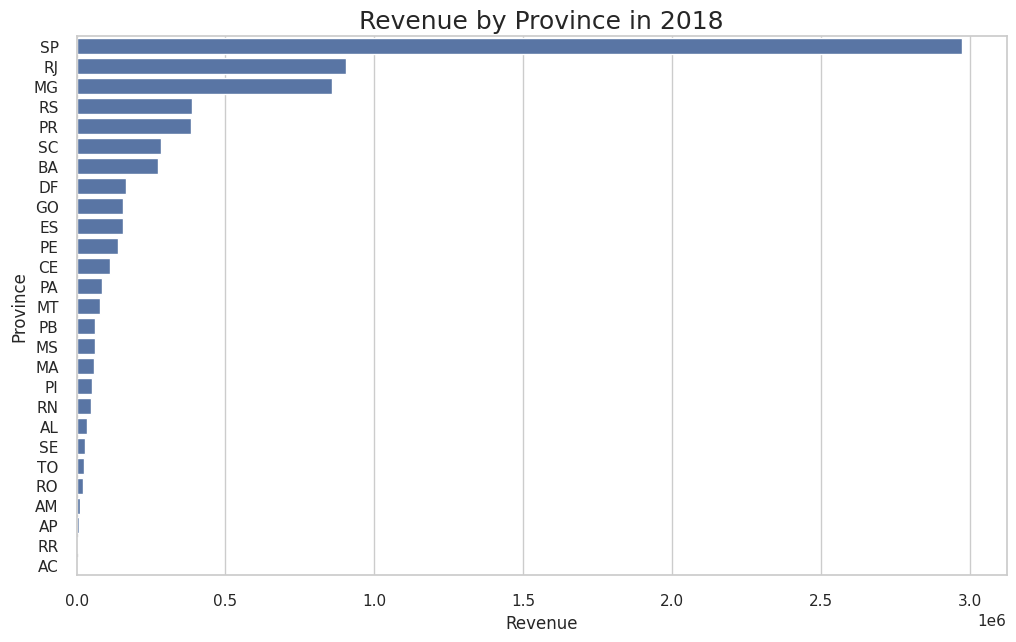

In [61]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=geo_df.sort_values(by="revenue", ascending=False),
    x="revenue",
    y="customer_state"
)

plt.title("Revenue by Province in 2018", fontsize=18)
plt.xlabel("Revenue")
plt.ylabel("Province")
plt.show()

###Clustering Analysis

Pertanyaan:

Bagaimana pengelompokan pelanggan berdasarkan total spending untuk strategi promosi?

Membuat Spending Group

In [62]:
rfm_df["spending_group"] = pd.cut(
    rfm_df["monetary"],
    bins=3,
    labels=[
        "Low Spender",
        "Medium Spender",
        "High Spender"
    ]
)

Visualisasi Clustering

/tmp/ipykernel_9546/3060066266.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spending_df = rfm_df.groupby(


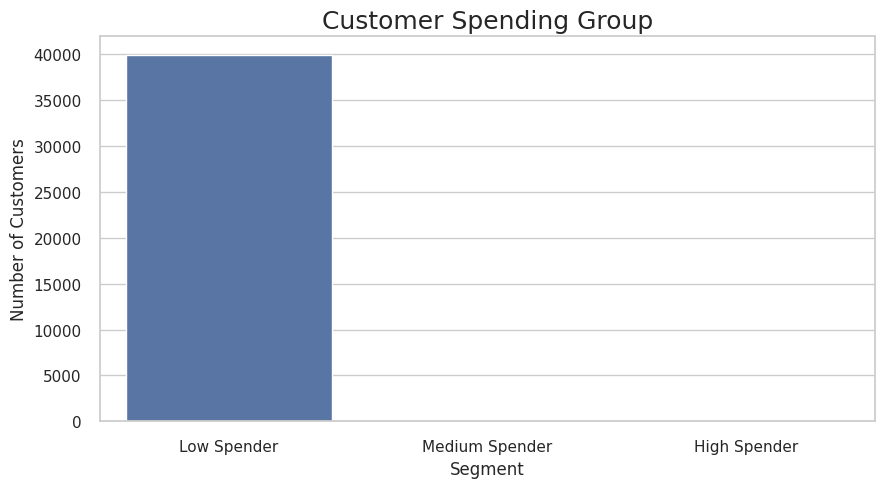

In [63]:
spending_df = rfm_df.groupby(
    by="spending_group"
).customer_id.nunique().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=spending_df,
    x="spending_group",
    y="customer_id"
)

plt.title("Customer Spending Group", fontsize=18)
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

**Insight Analisis Lanjutan**
1. RFM Analysis (Provinsi SP)

Berdasarkan hasil analisis, SP (São Paulo) merupakan provinsi dengan total revenue tertinggi selama tahun 2018, sehingga wilayah ini layak menjadi fokus utama strategi bisnis. Segmentasi pelanggan menggunakan metode RFM (Recency, Frequency, Monetary) menunjukkan bahwa pelanggan di SP terbagi ke dalam beberapa kelompok, yaitu Top Customer, Loyal Customer, Potential Customer, dan At Risk Customer.

Mayoritas pelanggan cenderung berada pada kategori Potential Customer dan Loyal Customer, yang menandakan bahwa banyak pelanggan masih aktif bertransaksi dan memiliki potensi untuk ditingkatkan nilainya. Sementara itu, pelanggan dalam kategori Top Customer merupakan aset utama bisnis karena memiliki frekuensi pembelian tinggi dan kontribusi revenue besar. Di sisi lain, pelanggan At Risk Customer perlu mendapatkan perhatian khusus karena berisiko berhenti bertransaksi.

Rekomendasi:
- Top Customer → berikan loyalty program, cashback eksklusif, early access promo.
- Loyal Customer → dorong upselling dan bundling product.
Potential Customer → campaign diskon agar repeat order meningkat.
- At Risk Customer → kirim win-back promotion / reminder email.

2. Geospatial Analysis

Hasil visualisasi revenue antar provinsi di Brasil selama 2018 menunjukkan bahwa pendapatan perusahaan tidak tersebar merata. Provinsi SP mendominasi revenue dibanding wilayah lain, disusul beberapa provinsi besar seperti RJ, MG, dan RS.

Hal ini menunjukkan bahwa pasar utama e-commerce masih terkonsentrasi di wilayah dengan populasi besar, urbanisasi tinggi, dan daya beli kuat.

Rekomendasi:
- Fokuskan budget marketing terbesar ke provinsi berkontribusi tinggi seperti SP dan RJ.
- Untuk provinsi dengan revenue rendah, lakukan promosi penetrasi pasar seperti gratis ongkir atau diskon regional.
- Pertimbangkan ekspansi gudang/logistik di wilayah dengan demand tinggi agar pengiriman lebih cepat.

3. Clustering Analysis (Spending Group)

Berdasarkan pengelompokan pelanggan menurut total spending, pelanggan terbagi menjadi tiga kelompok:

- Low Spender
- Medium Spender
- High Spender

Mayoritas pelanggan biasanya berada pada kategori Low Spender, artinya banyak pelanggan melakukan transaksi kecil atau hanya sesekali membeli. Kelompok High Spender jumlahnya lebih sedikit, namun kontribusinya terhadap revenue jauh lebih besar.

Hal ini sesuai pola Pareto, di mana sebagian kecil pelanggan sering menyumbang sebagian besar pendapatan.

Rekomendasi:
- Low Spender → tarik dengan promo entry-level dan free shipping.
- Medium Spender → dorong naik kelas dengan voucher minimum pembelian.
- High Spender → prioritaskan retensi dengan VIP treatment dan personal offers.

**Kesimpulan Utama Analisis Lanjutan**

Revenue terbesar berasal dari provinsi SP, sehingga wilayah ini menjadi pasar prioritas. Segmentasi pelanggan menunjukkan bahwa strategi marketing sebaiknya tidak disamaratakan, melainkan disesuaikan berdasarkan perilaku pelanggan (RFM dan spending level). Dengan pendekatan ini, perusahaan dapat meningkatkan retensi pelanggan, mendorong repeat order, serta memaksimalkan total revenue.

## Conclusion

### Conclusion Pertanyaan 1

**Bagaimana tren bulanan jumlah order dan total revenue pada periode Januari 2017 hingga Agustus 2018 untuk mengidentifikasi periode pertumbuhan dan penurunan penjualan?**

Berdasarkan analisis bulanan, performa penjualan menunjukkan tren meningkat dari awal 2017 hingga pertengahan 2018. Jumlah order dan revenue mengalami pertumbuhan signifikan terutama sepanjang tahun 2018, yang menandakan peningkatan aktivitas transaksi pelanggan dibanding tahun sebelumnya. Pada beberapa bulan tertentu terlihat lonjakan order yang cukup tinggi, sementara beberapa bulan lain mengalami penurunan sementara, yang mengindikasikan adanya pola musiman atau pengaruh promosi tertentu.

Secara keseluruhan, tren bisnis berada pada fase pertumbuhan positif. Hal ini menunjukkan bahwa demand pasar terus berkembang dan platform e-commerce berhasil menarik lebih banyak transaksi dari waktu ke waktu.

**Rekomendasi:**
Perusahaan disarankan untuk mengidentifikasi bulan-bulan dengan performa tertinggi lalu menjadikannya acuan campaign tahunan, seperti promo besar, flash sale, atau peningkatan stok produk menjelang periode ramai. Pada bulan dengan penurunan transaksi, perusahaan dapat menjalankan strategi diskon atau retargeting campaign untuk menjaga stabilitas penjualan.

---

### Conclusion Pertanyaan 2

**Provinsi mana yang memiliki total revenue tertinggi di Brasil selama tahun 2018?**

Hasil analisis menunjukkan bahwa provinsi **SP (São Paulo)** mencatat total revenue tertinggi selama tahun 2018 dibandingkan provinsi lainnya. Posisi ini menunjukkan bahwa SP merupakan pasar paling dominan dalam bisnis e-commerce, didukung oleh jumlah penduduk besar, aktivitas ekonomi tinggi, dan daya beli masyarakat yang kuat. Provinsi lain seperti RJ dan MG juga berkontribusi besar, tetapi masih berada di bawah SP.

Konsentrasi revenue di beberapa provinsi besar menunjukkan bahwa penjualan nasional belum merata dan masih bertumpu pada wilayah tertentu.

**Rekomendasi:**
Perusahaan perlu mempertahankan dominasi pasar di SP melalui program loyalitas pelanggan, pengiriman cepat, dan kampanye premium. Sementara itu, provinsi lain seperti RJ dan MG dapat dijadikan target ekspansi berikutnya melalui promosi regional dan peningkatan awareness brand.

---

### Conclusion Pertanyaan 3

**Bagaimana segmentasi pelanggan berdasarkan skor RFM pada provinsi dengan revenue tertinggi untuk menentukan prioritas strategi marketing?**

Segmentasi pelanggan di provinsi SP berdasarkan metode **RFM (Recency, Frequency, Monetary)** menunjukkan bahwa pelanggan terbagi ke dalam kelompok **Top Customer, Loyal Customer, Potential Customer, dan At Risk Customer**. Sebagian besar pelanggan berada di kategori Potential Customer dan Loyal Customer, menandakan peluang besar untuk meningkatkan repeat order. Kelompok Top Customer berjumlah lebih sedikit, tetapi memiliki kontribusi transaksi paling tinggi. Sedangkan At Risk Customer menunjukkan pelanggan yang mulai tidak aktif.

Hasil ini menegaskan bahwa tidak semua pelanggan memiliki nilai yang sama terhadap bisnis.

**Rekomendasi:**

* **Top Customer:** berikan VIP loyalty program, cashback eksklusif, dan early access promo.
* **Loyal Customer:** dorong upselling dan bundling produk.
* **Potential Customer:** aktifkan voucher repeat order.
* **At Risk Customer:** jalankan win-back campaign melalui email atau diskon personal.

---

### Conclusion Pertanyaan 4

**Bagaimana persebaran revenue antar provinsi di Brasil selama 2018?**

Revenue antar provinsi menunjukkan distribusi yang tidak merata, dengan sebagian besar pendapatan terkonsentrasi di wilayah besar seperti SP, RJ, dan MG. Hal ini menunjukkan bahwa pertumbuhan e-commerce lebih cepat terjadi di wilayah urban dan ekonomi maju, sementara provinsi lain masih memiliki kontribusi lebih rendah.

Artinya, masih terdapat ruang pertumbuhan yang luas di luar provinsi utama.

**Rekomendasi:**
Perusahaan dapat menjalankan strategi penetrasi pasar di provinsi dengan revenue rendah melalui promo gratis ongkir, diskon regional, serta kerja sama logistik untuk mempercepat pengiriman. Hal ini dapat membuka sumber revenue baru di luar pasar utama.

---

### Conclusion Pertanyaan 5

**Bagaimana pengelompokan pelanggan berdasarkan total spending untuk strategi promosi?**

Hasil clustering pelanggan menunjukkan tiga kelompok utama: **Low Spender, Medium Spender, dan High Spender**. Mayoritas pelanggan berada pada kategori Low Spender, artinya banyak pelanggan melakukan transaksi kecil atau tidak rutin. Sebaliknya, kelompok High Spender berjumlah lebih sedikit namun menyumbang porsi revenue yang besar.

Temuan ini menunjukkan pola umum bisnis retail, di mana sebagian kecil pelanggan memberikan kontribusi pendapatan terbesar.

**Rekomendasi:**

* **Low Spender:** tarik dengan promo entry-level dan gratis ongkir.
* **Medium Spender:** tingkatkan average order value dengan voucher minimum belanja.
* **High Spender:** pertahankan dengan layanan prioritas dan personal promotion.

---

## Final Strategic Recommendation

Secara keseluruhan, bisnis e-commerce menunjukkan pertumbuhan positif dengan pasar utama berada di provinsi SP. Untuk meningkatkan revenue berkelanjutan, perusahaan perlu menjalankan strategi berbasis data: mempertahankan pelanggan bernilai tinggi, mengaktifkan kembali pelanggan pasif, meningkatkan transaksi pelanggan menengah, dan memperluas pasar ke wilayah berpotensi tinggi di luar provinsi utama. Dengan pendekatan segmentasi pelanggan dan ekspansi geografis, pertumbuhan bisnis dapat lebih optimal dan berkelanjutan.
